In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('train.csv')

# Sanity checks
print(df.shape)
print(df.dtypes)
df.head()

(80000, 41)
runner_id                          object
age                                 int64
gender                             object
running_experience_months           int64
previous_marathon_count             int64
training_program                   object
motivation_level                    int64
personal_best_minutes             float64
weekly_mileage_km                 float64
weekly_mileage_miles              float64
runs_per_week                       int64
long_run_distance_km              float64
speed_work_sessions_per_week        int64
rest_days_per_week                  int64
training_adherence_pct              int64
consecutive_weeks_no_miss           int64
cross_training_hours_per_week     float64
resting_heart_rate_bpm              int64
vo2_max                           float64
bmi                               float64
recovery_score                    float64
sleep_hours_avg                   float64
injury_count                        int64
injury_severity       

,runner_id,age,gender,running_experience_months,previous_marathon_count,training_program,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,...,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,marathon_date,marathon_weather,course_difficulty,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score,medal_outcome
0,R009432,25,Male,48,0,Intermediate,4,NaN,20.0,12.4,...,0,70,29,2025-02-02,Hot,Mixed,254,297.0,5,0
1,R077741,43,Female,151,2,Advanced,1,196.0,20.0,12.4,...,0,94,0,2024-02-11,Sunny,Mixed,201,231.0,7,1
2,R034376,32,Female,82,3,Advanced,6,211.0,23.1,14.4,...,54,47,39,2025-03-27,Rainy,Flat,204,234.0,9,1
3,R020754,57,Male,6,0,Beginner,8,NaN,27.3,17.0,...,63,77,45,2024-04-16,Sunny,Hilly,258,276.0,3,3
4,R001301,54,Female,11,0,Beginner,3,NaN,20.0,12.4,...,20,64,40,2025-10-21,Cloudy,Mixed,245,296.0,8,0


In [4]:
pd.read_csv('train.csv').columns.tolist()

['runner_id',
 'age',
 'gender',
 'running_experience_months',
 'previous_marathon_count',
 'training_program',
 'motivation_level',
 'personal_best_minutes',
 'weekly_mileage_km',
 'weekly_mileage_miles',
 'runs_per_week',
 'long_run_distance_km',
 'speed_work_sessions_per_week',
 'rest_days_per_week',
 'training_adherence_pct',
 'consecutive_weeks_no_miss',
 'cross_training_hours_per_week',
 'resting_heart_rate_bpm',
 'vo2_max',
 'bmi',
 'recovery_score',
 'sleep_hours_avg',
 'injury_count',
 'injury_severity',
 'nutrition_score',
 'hydration_consistency',
 'training_streak_days',
 'missed_workout_pct',
 'early_morning_run_frequency',
 'weather_condition_training_pct',
 'goal_completion_rate',
 'run_club_attendance_rate',
 'warmup_adherence_pct',
 'stretching_adherence_pct',
 'marathon_date',
 'marathon_weather',
 'course_difficulty',
 'target_finish_time_minutes',
 'actual_finish_time_minutes',
 'mental_preparation_score',
 'medal_outcome']

In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   runner_id                       80000 non-null  object 
 1   age                             80000 non-null  int64  
 2   gender                          80000 non-null  object 
 3   running_experience_months       80000 non-null  int64  
 4   previous_marathon_count         80000 non-null  int64  
 5   training_program                80000 non-null  object 
 6   motivation_level                80000 non-null  int64  
 7   personal_best_minutes           69255 non-null  float64
 8   weekly_mileage_km               80000 non-null  float64
 9   weekly_mileage_miles            80000 non-null  float64
 10  runs_per_week                   80000 non-null  int64  
 11  long_run_distance_km            80000 non-null  float64
 12  speed_work_sessions_per_week    

runner_id                             0
age                                   0
gender                                0
running_experience_months             0
previous_marathon_count               0
training_program                      0
motivation_level                      0
personal_best_minutes             10745
weekly_mileage_km                     0
weekly_mileage_miles                  0
runs_per_week                         0
long_run_distance_km                  0
speed_work_sessions_per_week          0
rest_days_per_week                    0
training_adherence_pct                0
consecutive_weeks_no_miss             0
cross_training_hours_per_week      7983
resting_heart_rate_bpm                0
vo2_max                            9611
bmi                                   0
recovery_score                        0
sleep_hours_avg                    3942
injury_count                          0
injury_severity                   47350
nutrition_score                    6402


<Axes: xlabel='actual_finish_time_minutes', ylabel='Count'>

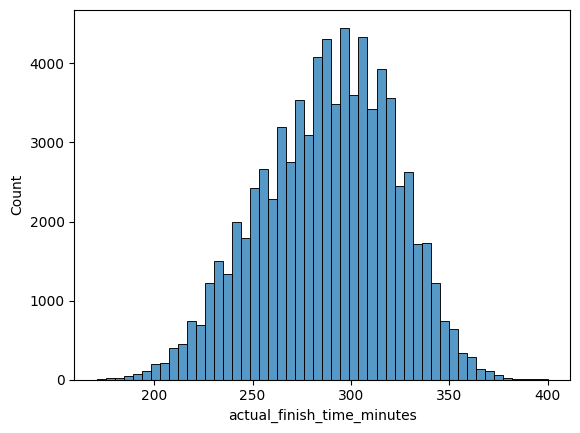

In [6]:
# Target distribution
sns.histplot(df['actual_finish_time_minutes'], bins=50)

In [7]:
df[['target_finish_time_minutes', 'actual_finish_time_minutes']].describe()


,target_finish_time_minutes,actual_finish_time_minutes
count,80000.000000,78011.000000
mean,249.308687,287.931407
std,30.372115,33.648005
min,150.000000,171.000000
25%,228.000000,265.000000
50%,252.000000,290.000000
75%,272.000000,313.000000
max,350.000000,400.000000


In [8]:
# Categorical features
df.select_dtypes(include='object').columns.tolist()

['runner_id',
 'gender',
 'training_program',
 'injury_severity',
 'marathon_date',
 'marathon_weather',
 'course_difficulty']

# BASELINE MODEL

## V1 Preprocessing

In [9]:
# Ordinal mappings
training_map = {"Beginner": 1, "Intermediate": 2, "Advanced": 3}
course_map = {"Flat": 1, "Mixed": 2, "Hilly": 3}
injury_map = {"Minor": 1, "Moderate": 2, "Severe": 3}

df['training_program'] = df['training_program'].map(training_map)
df['course_difficulty'] = df['course_difficulty'].map(course_map)
df['injury_severity'] = df['injury_severity'].map(injury_map).fillna(0)

# Nominal — one-hot on full df
ohe = OneHotEncoder(drop='first', sparse_output=False)
ohe_array = ohe.fit_transform(df[['gender', 'marathon_weather']])
ohe_df = pd.DataFrame(ohe_array,
                      columns=ohe.get_feature_names_out(['gender', 'marathon_weather']),
                      index=df.index)

df = df.drop(columns=['gender', 'marathon_weather'])
df = pd.concat([df, ohe_df], axis=1)

# Confirm
print(df.shape)
print(df.select_dtypes(include='object').columns.tolist())

(80000, 46)
['runner_id', 'marathon_date']


In [10]:
# Minimum Drop List

minimum_drop_list = [
   "runner_id",
    "weekly_mileage_miles",
    "target_finish_time_minutes",
    "medal_outcome",
    "marathon_date",
    "personal_best_minutes"
]

df_v1 = df.drop(columns=[c for c in minimum_drop_list if c in df.columns])
print(df.shape)

(80000, 46)


In [11]:
# Dropping DNFs => different problem
df_v1 = df_v1[df_v1['actual_finish_time_minutes'].notna()].copy()

In [12]:
df_v1.isnull().sum()[df.isnull().sum() > 0]

cross_training_hours_per_week    7783
vo2_max                          9362
sleep_hours_avg                  3840
nutrition_score                  6255
hydration_consistency            6271
actual_finish_time_minutes          0
dtype: int64

In [13]:
X_v1 = df_v1.drop(columns=['actual_finish_time_minutes'])
y_v1 = df_v1['actual_finish_time_minutes']

In [14]:
# Impute Median on remaining missing values
X_v1 = X_v1.fillna(X_v1.median(numeric_only=True))

In [15]:
X_train_v1, X_test_v1, y_train_v1, y_test_v1 = train_test_split(X_v1, y_v1, test_size=0.2, random_state=42)

In [16]:
# Train the model
model_v1 = LinearRegression()
model_v1.fit(X_train_v1, y_train_v1)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
# Evaluate the model
y_pred_v1 = model_v1.predict(X_test_v1)

In [18]:
print(f"Baseline R2 Score: {r2_score(y_test_v1, y_pred_v1):.4f}")
print(f"Baseline MAE: {mean_absolute_error(y_test_v1, y_pred_v1):.2f} minutes")

Baseline R2 Score: 0.6350
Baseline MAE: 16.12 minutes


## Model V2 - extended feature drop list

In [19]:
extended_drop_list = [
    # Minimum drops
    "runner_id",
    "weekly_mileage_miles",
    "target_finish_time_minutes",
    "medal_outcome",
    "marathon_date",
    "personal_best_minutes",

    # Gender — dropping after OHE to keep preprocessing constant
    "gender_Male",
    "gender_Non-binary",

    # Near-zero correlation
    "previous_marathon_count",
    "hydration_consistency",
    "bmi",

    # Redundant
    "training_streak_days",
    "missed_workout_pct",

    # Race day factors
    "marathon_weather_Cold",
    "marathon_weather_Rainy",
    "marathon_weather_Windy",
    "marathon_weather_Hot",
    "marathon_weather_Sunny",
    "course_difficulty",
]

df_v2 = df.drop(columns=[c for c in extended_drop_list if c in df.columns])
print(df_v2.shape)

(80000, 27)


In [20]:
# DNF filter
df_v2 = df_v2[df_v2['actual_finish_time_minutes'].notna()].copy()

# Split X and y
X_v2 = df_v2.drop(columns=['actual_finish_time_minutes'])
y_v2 = df_v2['actual_finish_time_minutes']

# Impute
X_v2 = X_v2.fillna(X_v2.median(numeric_only=True))

# Train test split
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(X_v2, y_v2, test_size=0.2, random_state=42)

# Train model
model_v2 = LinearRegression()
model_v2.fit(X_train_v2, y_train_v2)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_pred_v2 = model_v2.predict(X_test_v2)

In [22]:
print(f"Baseline R2 Score: {r2_score(y_test_v2, y_pred_v2):.4f}")
print(f"Baseline MAE: {mean_absolute_error(y_test_v2, y_pred_v2):.2f} minutes")

Baseline R2 Score: 0.6159
Baseline MAE: 16.57 minutes


## Model V3 - XBoost on V1 drop list

In [23]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [24]:
%pip show xgboost

Name: xgboost
Version: 2.0.3
Summary: XGBoost Python Package
Home-page: 
Author: 
Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
License: Apache-2.0
Location: /Users/cfk/.pyenv/versions/3.10.6/envs/MarathonIQ/lib/python3.10/site-packages
Requires: numpy, scipy
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [25]:
%pip install xgboost==2.0.3

Note: you may need to restart the kernel to use updated packages.


In [26]:
from xgboost import XGBRegressor

model_xgb_v1 = XGBRegressor(random_state=42)

scores_mae = cross_val_score(model_xgb_v1, X_train_v1, y_train_v1,
                             cv=5,
                             scoring='neg_mean_absolute_error')

scores_r2 = cross_val_score(model_xgb_v1, X_train_v1, y_train_v1,
                            cv=5,
                            scoring='r2')

print(f"XGBoost MAE: {-scores_mae.mean():.1f} minutes")
print(f"XGBoost R2: {scores_r2.mean():.3f}")

XGBoost MAE: 16.5 minutes
XGBoost R2: 0.624


In [27]:
# Check baseline v1 scores for comparison
print(f"LinReg MAE: 16.12 minutes")
print(f"LinReg R2: 0.6350")
print(f"XGBoost MAE: 16.5 minutes")
print(f"XGBoost R2: 0.624")

LinReg MAE: 16.12 minutes
LinReg R2: 0.6350
XGBoost MAE: 16.5 minutes
XGBoost R2: 0.624


XGBoost worse than LinReg...

## Model V3 - XGBoost on V1 drop list - tuned

In [28]:
model_xgb_v1 = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=6,
    random_state=42,
)

scores_mae = cross_val_score(model_xgb_v1, X_train_v1, y_train_v1,
                             cv=5,
                             scoring='neg_mean_absolute_error')

scores_r2 = cross_val_score(model_xgb_v1, X_train_v1, y_train_v1,
                            cv=5,
                            scoring='r2')

print(f"XGBoost tuned MAE: {-scores_mae.mean():.1f} minutes")
print(f"XGBoost tuned R2: {scores_r2.mean():.3f}")

XGBoost tuned MAE: 16.1 minutes
XGBoost tuned R2: 0.642


XGBoost matches LinReg only after tuning - are relationships largely linear because data is synthetic?

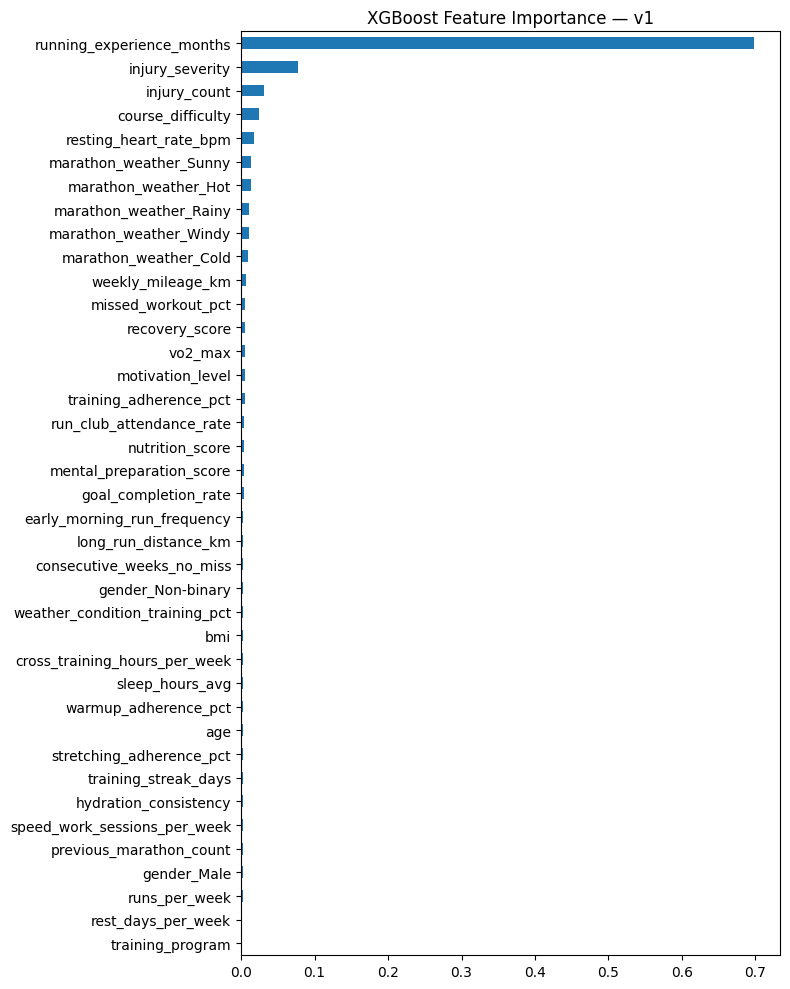

In [29]:
# Fit on full training data
model_xgb_v1.fit(X_train_v1, y_train_v1)

# Plot feature importance
feat_importance = pd.Series(
    model_xgb_v1.feature_importances_,
    index=X_train_v1.columns
).sort_values(ascending=True)

# Visualizec
feat_importance.plot(kind='barh', figsize=(8, 10))
plt.axvline(0, color='black', linewidth=0.5)
plt.title('XGBoost Feature Importance — v1')
plt.tight_layout()

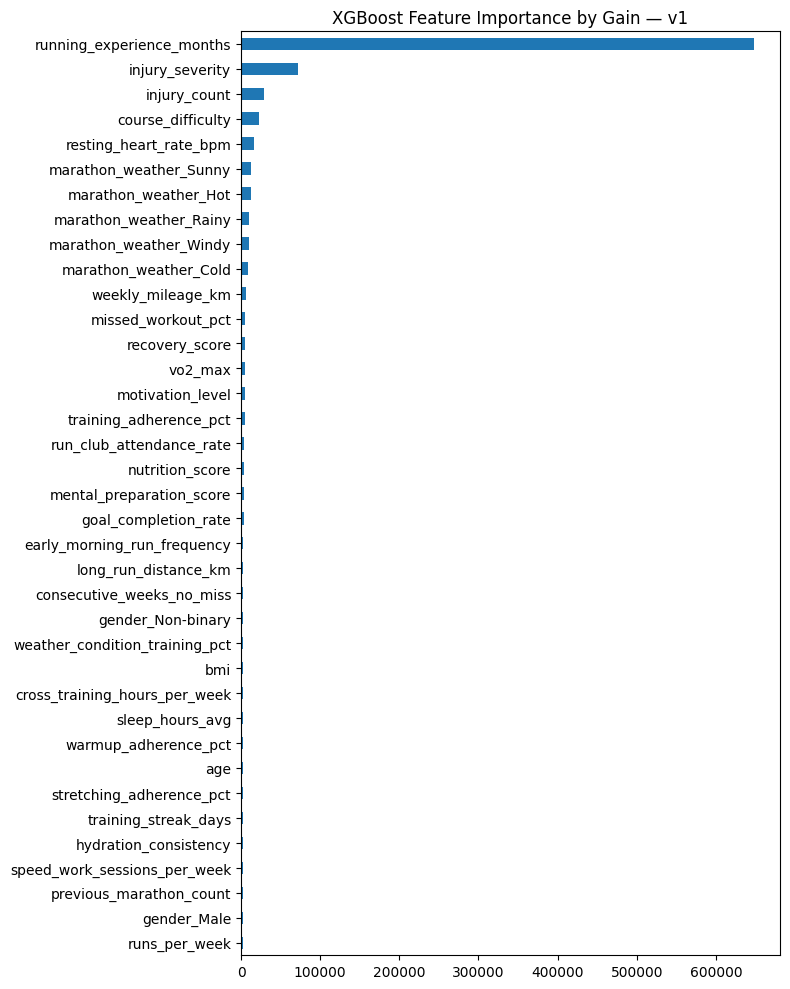

In [30]:
feat_importance_gain = pd.Series(
    model_xgb_v1.get_booster().get_score(importance_type='gain'),
    ).sort_values(ascending=True)

feat_importance_gain.plot(kind='barh', figsize=(8, 10))
plt.title('XGBoost Feature Importance by Gain — v1')
plt.tight_layout()

In [31]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [32]:
import shap
import xgboost

In [33]:
print(shap.__version__)
print(xgboost.__version__)

0.49.1
2.0.3


In [34]:
%pip install --upgrade shap

Note: you may need to restart the kernel to use updated packages.


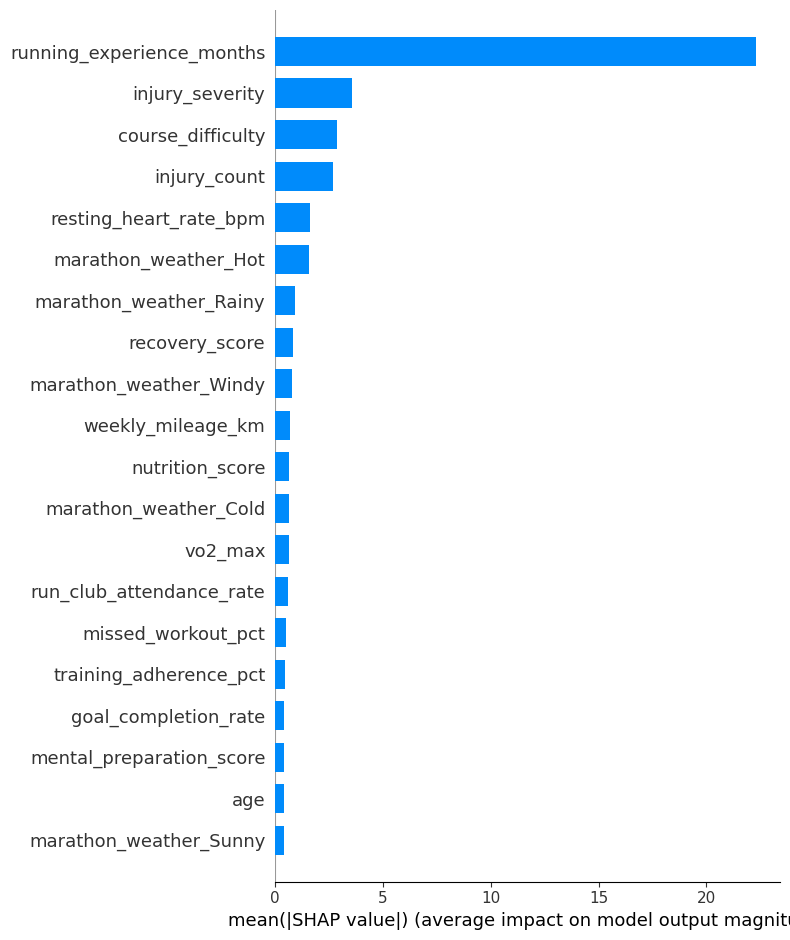

In [35]:
import shap
# Create explainer
explainer = shap.TreeExplainer(model_xgb_v1)
shap_values = explainer.shap_values(X_train_v1)

# Summary plot — direction + magnitude
shap.summary_plot(shap_values, X_train_v1, plot_type='bar')


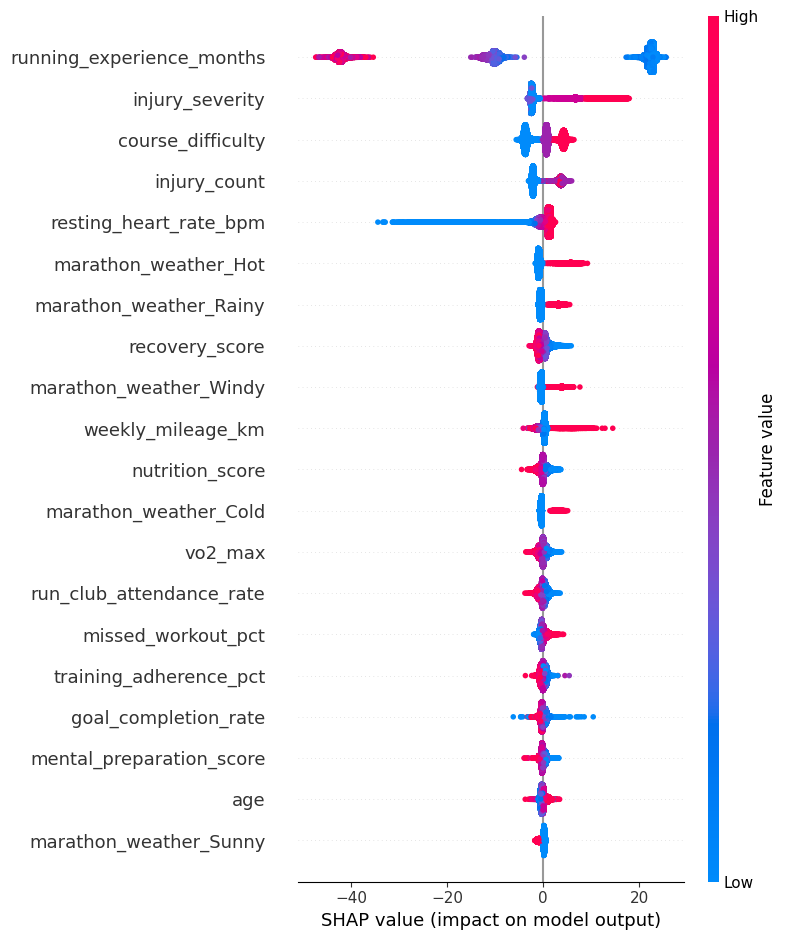

In [36]:
shap.summary_plot(shap_values, X_train_v1)

In [37]:
print(f"Features in X_train_v1: {X_train_v1.shape[1]}")
print(f"Features in SHAP plot: {len(feat_importance_gain)}")

Features in X_train_v1: 39
Features in SHAP plot: 37


In [38]:
shap_features = set(feat_importance_gain.index)
all_features = set(X_train_v1.columns)

ignored = all_features - shap_features
print(ignored)

{'training_program', 'rest_days_per_week'}


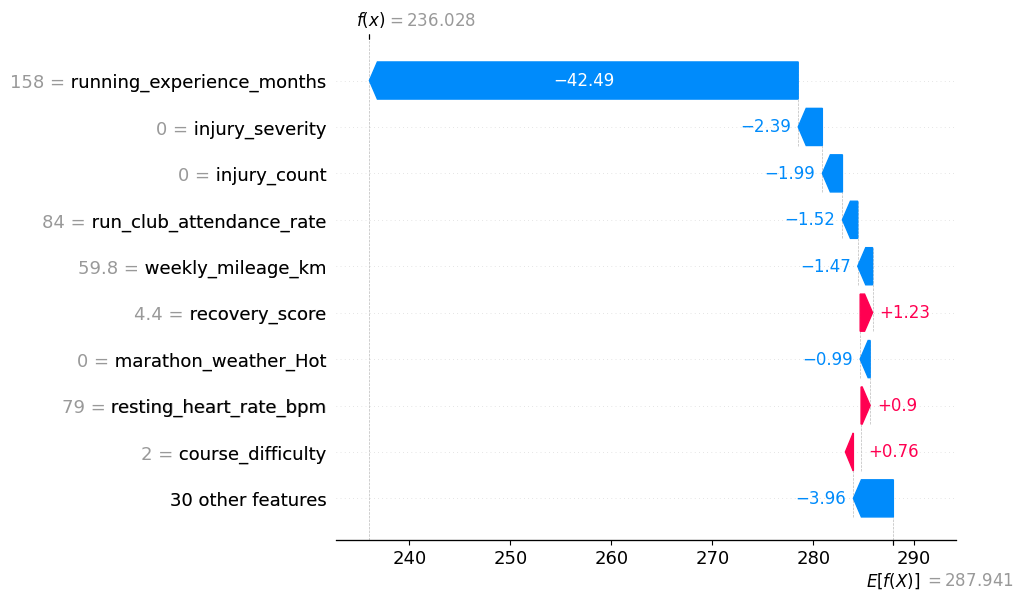

In [39]:
# Pick one runner
sample = X_train_v1.iloc[[0]]

# Get SHAP values for that runner
shap_values_sample = explainer(sample)

# Waterfall plot
shap.plots.waterfall(shap_values_sample[0], max_display=10)

## MVP for runner predicition overview (based on SHAP value)

- E[f(x)] = 287.94 min → average predicted finish time across all runners (4h48)
- f(x) = 236 min → this runner's predicted finish time (3h56)

What's driving the difference:
- running_experience_months = 158 → -42 minutes — massive positive impact, very experienced runner
- injury_severity = 0 → -2.4 min — no injury, helps slightly
- injury_count = 0 → -2.0 min — same
- weekly_mileage_km = 59.8 → -1.5 min — decent mileage helps
- recovery_score = 4.4 → +1.2 min — low recovery score, costing time
- resting_heart_rate = 79 → +0.9 min — slightly high HR, costing time
- course_difficulty = 2 → +0.76 min — mixed course, slight cost
- Only the top X features are displayed

In [40]:
# Mean absolute SHAP value per feature
mean_shap = pd.Series(
    abs(shap_values).mean(axis=0),
    index=X_train_v1.columns
).sort_values(ascending=False)

print(mean_shap)

running_experience_months         22.301279
injury_severity                    3.578258
course_difficulty                  2.882787
injury_count                       2.700409
resting_heart_rate_bpm             1.614612
marathon_weather_Hot               1.575452
marathon_weather_Rainy             0.926499
recovery_score                     0.815274
marathon_weather_Windy             0.779251
weekly_mileage_km                  0.682404
nutrition_score                    0.656659
marathon_weather_Cold              0.656390
vo2_max                            0.618722
run_club_attendance_rate           0.598197
missed_workout_pct                 0.491489
training_adherence_pct             0.432739
goal_completion_rate               0.421113
mental_preparation_score           0.395845
age                                0.392896
marathon_weather_Sunny             0.389563
bmi                                0.245088
motivation_level                   0.229834
warmup_adherence_pct            

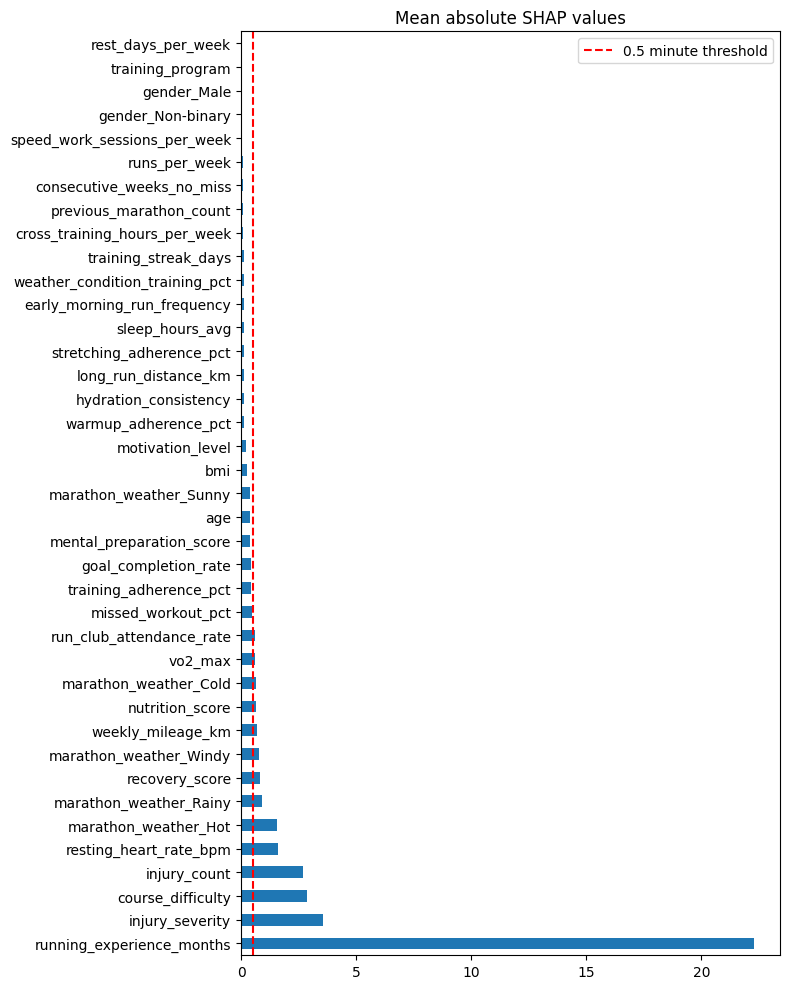

In [41]:
mean_shap.plot(kind='barh', figsize=(8, 10))
plt.axvline(0.5, color='red', linestyle='--', label='0.5 minute threshold')
plt.title('Mean absolute SHAP values')
plt.legend()
plt.tight_layout()

In [42]:
# Mean absolute SHAP per feature
mean_shap_abs = pd.Series(
    abs(shap_values).mean(axis=0),
    index=X_train_v1.columns
).sort_values(ascending=False)

# Apply threshold
threshold = 0.5

kept = mean_shap_abs[mean_shap_abs > threshold].reset_index()
kept.columns = ['feature', 'mean_abs_shap']
kept['decision'] = 'keep'

dropped = mean_shap_abs[mean_shap_abs <= threshold].reset_index()
dropped.columns = ['feature', 'mean_abs_shap']
dropped['decision'] = 'drop'

# Combined table
feature_table = pd.concat([kept, dropped]).reset_index(drop=True)
feature_table['mean_abs_shap'] = feature_table['mean_abs_shap'].round(3)

print(f"Keeping: {len(kept)} features")
print(f"Dropping: {len(dropped)} features")
print(f"\n{feature_table.to_string(index=False)}")

Keeping: 14 features
Dropping: 25 features

                       feature  mean_abs_shap decision
     running_experience_months      22.301001     keep
               injury_severity       3.578000     keep
             course_difficulty       2.883000     keep
                  injury_count       2.700000     keep
        resting_heart_rate_bpm       1.615000     keep
          marathon_weather_Hot       1.575000     keep
        marathon_weather_Rainy       0.926000     keep
                recovery_score       0.815000     keep
        marathon_weather_Windy       0.779000     keep
             weekly_mileage_km       0.682000     keep
               nutrition_score       0.657000     keep
         marathon_weather_Cold       0.656000     keep
                       vo2_max       0.619000     keep
      run_club_attendance_rate       0.598000     keep
            missed_workout_pct       0.491000     drop
        training_adherence_pct       0.433000     drop
          goal_comple

## Model 3.1 XGB tuned with kept feature set (SHAP > 0.5 minutes)

In [43]:
# Features to keep based on SHAP threshold
keep_features = kept['feature'].tolist()

# Add target back
df_v3 = df_v1[keep_features + ['actual_finish_time_minutes']].copy()

print(df_v3.shape)
print(df_v3.columns.tolist())

(78011, 15)
['running_experience_months', 'injury_severity', 'course_difficulty', 'injury_count', 'resting_heart_rate_bpm', 'marathon_weather_Hot', 'marathon_weather_Rainy', 'recovery_score', 'marathon_weather_Windy', 'weekly_mileage_km', 'nutrition_score', 'marathon_weather_Cold', 'vo2_max', 'run_club_attendance_rate', 'actual_finish_time_minutes']


In [44]:
# DNF filter
df_v3 = df_v3[df_v3['actual_finish_time_minutes'].notna()].copy()

# Split X and y
X_v3 = df_v3.drop(columns=['actual_finish_time_minutes'])
y_v3 = df_v3['actual_finish_time_minutes']

# Impute
X_v3 = X_v3.fillna(X_v3.median(numeric_only=True))

# Train test split
X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_v3, y_v3, test_size=0.2, random_state=42
)

# Train XGBoost
model_xgb_v2 = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=6,
    random_state=42
)

scores_mae = cross_val_score(model_xgb_v2, X_train_v3, y_train_v3,
                             cv=5,
                             scoring='neg_mean_absolute_error')

scores_r2 = cross_val_score(model_xgb_v2, X_train_v3, y_train_v3,
                            cv=5,
                            scoring='r2')

print(f"XGBoost v2 MAE: {-scores_mae.mean():.1f} minutes")
print(f"XGBoost v2 R2: {scores_r2.mean():.3f}")
print(f"vs baseline XGBoost: 16.1 min / 0.642")

XGBoost v2 MAE: 16.1 minutes
XGBoost v2 R2: 0.640
vs baseline XGBoost: 16.1 min / 0.642


## Model V4 - Deep Learning Model on V1 drop list - No Dropout

In [45]:
%pip install tensorflow==2.16.2

Note: you may need to restart the kernel to use updated packages.


In [46]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

In [47]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_v1)
X_test_scaled = scaler.transform(X_test_v1)


es = EarlyStopping(patience=5, restore_best_weights=True)


# Simple model

model_dl_v1 = Sequential()

model_dl_v1.add(layers.Input(shape=(X_train_v1.shape[1],)))
model_dl_v1.add(layers.Dense(128, activation='relu'))
model_dl_v1.add(layers.Dense(64, activation='relu'))
model_dl_v1.add(layers.Dense(1))

# Compile
model_dl_v1.compile(
    optimizer='adam',
    loss='mae'
)

# Train
history = model_dl_v1.fit(
    X_train_scaled, y_train_v1,
    epochs=50,
    batch_size=128,
    validation_split=0.3,
    callbacks=[es],
    verbose=1
)

# Evaluate
mae_dl = model_dl_v1.evaluate(X_test_scaled, y_test_v1)
print(f"Deep Learning MAE: {mae_dl:.1f} minutes")

Epoch 1/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 795us/step - loss: 117.7648 - val_loss: 27.4735
Epoch 2/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 596us/step - loss: 24.0404 - val_loss: 22.0311
Epoch 3/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 713us/step - loss: 20.5589 - val_loss: 19.8117
Epoch 4/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 587us/step - loss: 18.8149 - val_loss: 18.5802
Epoch 5/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 623us/step - loss: 17.8829 - val_loss: 17.9877
Epoch 6/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 630us/step - loss: 17.2901 - val_loss: 17.5093
Epoch 7/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 744us/step - loss: 16.9460 - val_loss: 17.2001
Epoch 8/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 600us/step - loss: 16.7093 - val_loss: 17.2508
Epoch 9/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 584us/step - loss: 16.5582 - val_loss: 17.0638
Epoch 10/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 747us/step - loss: 16.4224 - val_loss: 16.8083
Epoch 11/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 603us/step - loss: 16.3165 - val_loss: 16.9481
Epoch 1

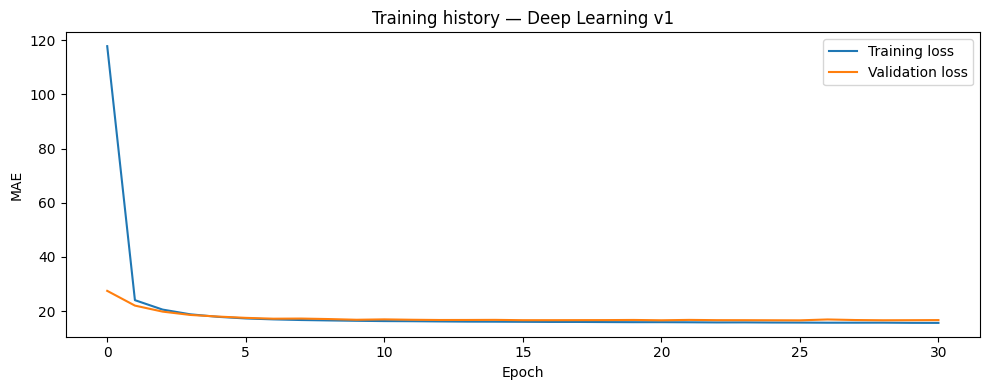

In [48]:
plt.figure(figsize=(10, 4))

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training history — Deep Learning v1')
plt.legend()
plt.tight_layout()

DL cannot beat best model: XGB tuned

## Model V5 - Deep Learning Model on V2 drop list - incl. Dropout

In [49]:
# Scale using v2 features
scaler_v2 = StandardScaler()
X_train_scaled_v2 = scaler_v2.fit_transform(X_train_v2)
X_test_scaled_v2 = scaler_v2.transform(X_test_v2)

es = EarlyStopping(patience=5, restore_best_weights=True)

model_dl_v2 = Sequential()
model_dl_v2.add(layers.Input(shape=(X_train_v2.shape[1],)))
model_dl_v2.add(layers.Dense(128, activation='relu'))
model_dl_v2.add(layers.Dropout(0.3))
model_dl_v2.add(layers.Dense(64, activation='relu'))
model_dl_v2.add(layers.Dropout(0.3))
model_dl_v2.add(layers.Dense(1))

model_dl_v2.compile(optimizer='adam', loss='mae')

history_v2 = model_dl_v3.fit(
    X_train_scaled_v2, y_train_v2,
    epochs=50,
    batch_size=128,
    validation_split=0.3,
    callbacks=[es],
    verbose=1
)

mae_dl_v3 = model_dl_v3.evaluate(X_test_scaled_v2, y_test_v2)
print(f"Deep Learning v3 (df_v2) MAE: {mae_dl_v3:.1f} minutes")

NameError: name 'model_dl_v3' is not defined

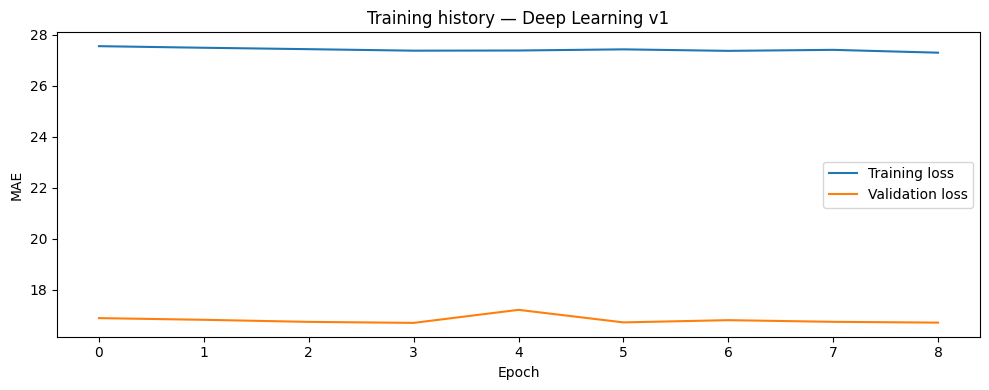

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(history_v2.history['loss'], label='Training loss')
plt.plot(history_v2.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training history — Deep Learning v1')
plt.legend()
plt.tight_layout()

Dropout and fewer features leads to inverted train and val loss - discard DL